<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 143 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Causal Inference</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">An observational loyalty program looks like a big win. We show the confounding hiding underneath, watch the naive difference mislead, then recover the true 120-dollar effect with regression adjustment and propensity-score weighting.</div>
</div>

Run top to bottom. Uses **pandas**, **statsmodels**, and **scikit-learn**. The data is simulated with a known true effect (**120 dollars**) so we can see which estimate is right.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD = "#a21caf", "#2563eb", "#16a34a", "#dc2626"
TRUE = 120     # the causal effect built into this simulated data
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "causal-inference--loyalty-program.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head())

(2000, 5)
  customer_id  prior_spend  tenure_months  enrolled   spend
0     C200000       202.39             42         0  294.92
1     C200001       295.18             39         1  631.32
2     C200002       285.73              7         1  564.11
3     C200003       164.28             14         0  327.24
4     C200004       179.14             48         0  373.30


## DEMO 1 &middot; Explore first: the naive comparison and its confounding
Enrolled customers really do spend more. But look at who enrolled: they already spent more and had been around longer, *before* the program existed. That imbalance is the confounding that makes the naive difference a lie.

          prior_spend  tenure_months  spend
enrolled                                   
0               181.0           28.4  387.1
1               243.7           36.9  582.8

NAIVE difference in mean spend = $195.8   (true effect is $120)


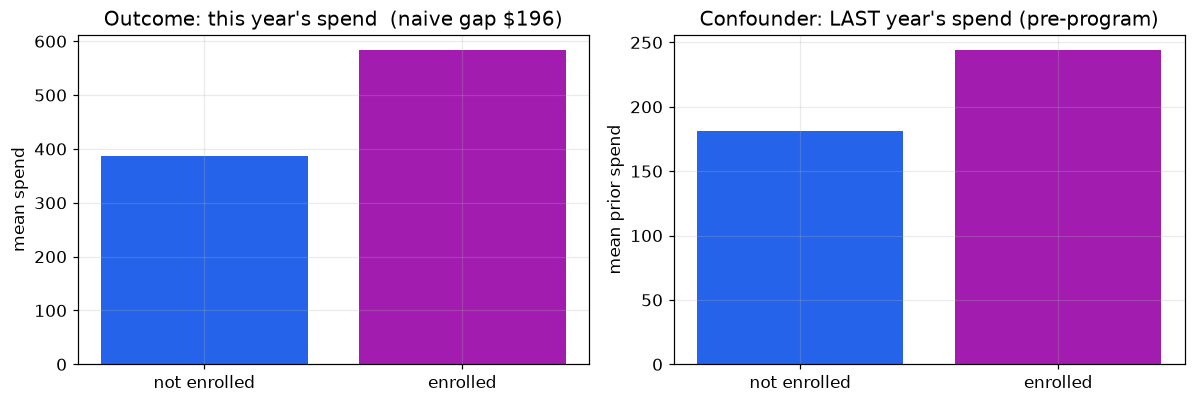

In [2]:
bal = df.groupby("enrolled")[["prior_spend", "tenure_months", "spend"]].mean().round(1)
print(bal)
naive = df.loc[df.enrolled==1, "spend"].mean() - df.loc[df.enrolled==0, "spend"].mean()
print(f"\nNAIVE difference in mean spend = ${naive:.1f}   (true effect is ${TRUE})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(["not enrolled", "enrolled"], bal["spend"], color=[BL, FU])
ax[0].set_title(f"Outcome: this year's spend  (naive gap ${naive:.0f})"); ax[0].set_ylabel("mean spend")
ax[1].bar(["not enrolled", "enrolled"], bal["prior_spend"], color=[BL, FU])
ax[1].set_title("Confounder: LAST year's spend (pre-program)"); ax[1].set_ylabel("mean prior spend")
plt.tight_layout(); plt.show()

## The picture: a causal DAG and the backdoor
Before adjusting, draw *why* the naive number is wrong. In a causal diagram an arrow means 'directly causes'. The confounders `prior_spend` and `tenure_months` point into BOTH `enrolled` and `spend`, opening a **backdoor path** `enrolled <- prior_spend -> spend` that carries non-causal association. Adjusting for the confounders blocks that path, leaving only the causal `enrolled -> spend` arrow.

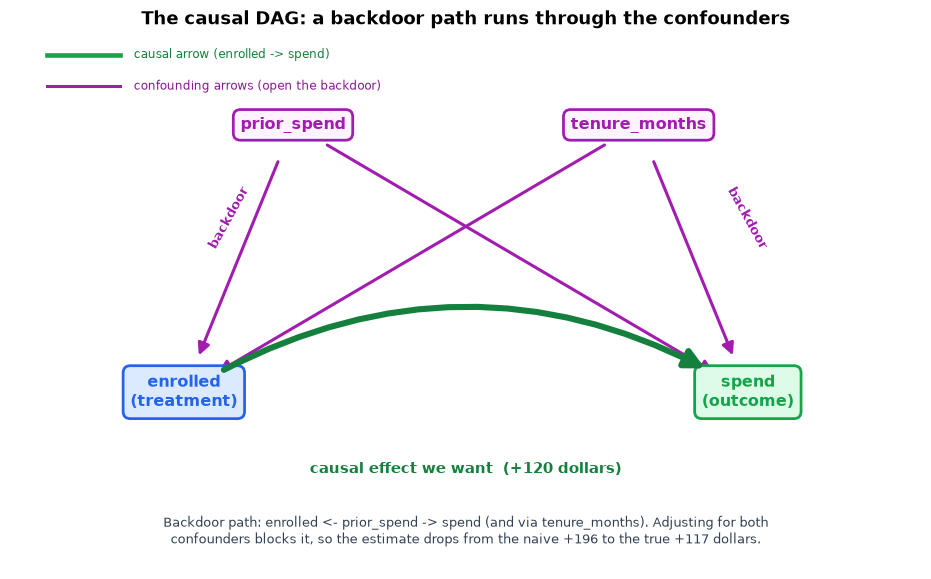

In [3]:
from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(figsize=(8.6, 5.4)); ax.set_xlim(0, 10); ax.set_ylim(-0.6, 7); ax.axis("off")

def node(x, y, label, fc, ec):
    ax.text(x, y, label, ha="center", va="center", fontsize=10.5, fontweight="bold", color=ec,
            bbox=dict(boxstyle="round,pad=0.45", fc=fc, ec=ec, lw=1.8), zorder=3)
    return (x, y)

ps = node(3.1, 5.7, "prior_spend",   "#fdf4ff", "#a21caf")   # confounder
tn = node(6.9, 5.7, "tenure_months", "#fdf4ff", "#a21caf")   # confounder
tr = node(1.9, 1.9, "enrolled\n(treatment)", "#dbeafe", "#2563eb")
ou = node(8.1, 1.9, "spend\n(outcome)",      "#dcfce7", "#16a34a")

def arrow(a, b, color, lw=2.0, ls="-"):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=16, color=color,
                                 lw=lw, ls=ls, shrinkA=26, shrinkB=26, zorder=2))

for cf in (ps, tn):                         # backdoor arrows: confounder -> BOTH
    arrow(cf, tr, "#a21caf"); arrow(cf, ou, "#a21caf")
# the causal effect we want: a bold green arc bowing into the clear space below the nodes
ax.add_patch(FancyArrowPatch(tr, ou, arrowstyle="-|>", mutation_scale=26, color="#15803d",
                             lw=4, shrinkA=30, shrinkB=32, zorder=6,
                             connectionstyle="arc3,rad=-0.30"))

ax.text(5.0, 0.75, "causal effect we want  (+120 dollars)", ha="center", fontsize=10,
        color="#15803d", fontweight="bold", zorder=7)
ax.text(2.15, 3.95, "backdoor", fontsize=8.5, color="#a21caf", fontweight="bold", rotation=61)
ax.text(7.85, 3.95, "backdoor", fontsize=8.5, color="#a21caf", fontweight="bold", rotation=-61)
# mini legend
ax.plot([0.4, 1.2], [6.7, 6.7], color="#16a34a", lw=3); ax.text(1.35, 6.7, "causal arrow (enrolled -> spend)", va="center", fontsize=8, color="#15803d")
ax.plot([0.4, 1.2], [6.25, 6.25], color="#a21caf", lw=2); ax.text(1.35, 6.25, "confounding arrows (open the backdoor)", va="center", fontsize=8, color="#86198f")
ax.set_title("The causal DAG: a backdoor path runs through the confounders", fontsize=11.5, fontweight="bold")
ax.text(5.0, -0.25, "Backdoor path: enrolled <- prior_spend -> spend (and via tenure_months). Adjusting for both\n"
        "confounders blocks it, so the estimate drops from the naive +196 to the true +117 dollars.",
        ha="center", fontsize=8.4, color="#334155")
plt.tight_layout(); plt.show()

## DEMO 2 &middot; Regression adjustment
Put the confounders in the model beside the treatment. The `enrolled` coefficient is now the effect *holding prior spend and tenure fixed*, the honest apples-to-apples comparison.

In [4]:
reg = smf.ols("spend ~ enrolled + prior_spend + tenure_months", data=df).fit()
adj = reg.params["enrolled"]; ci = reg.conf_int().loc["enrolled"]
print(f"adjusted effect of enrolling = ${adj:.1f}   95% CI [${ci[0]:.0f}, ${ci[1]:.0f}]")
print(f"(naive was ${naive:.0f}; true is ${TRUE})")
print(reg.summary().tables[1])

adjusted effect of enrolling = $117.1   95% CI [$111, $123]
(naive was $196; true is $120)
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       149.8621      4.714     31.790      0.000     140.617     159.107
enrolled        117.0829      3.108     37.671      0.000     110.988     123.178
prior_spend       0.9105      0.020     45.234      0.000       0.871       0.950
tenure_months     2.5510      0.076     33.674      0.000       2.402       2.700


## DEMO 3 &middot; Propensity scores and IPW
A second route to the same answer: model the probability of enrolling from the confounders (the propensity score), then reweight so treated and control groups look alike. The overlap of the two score distributions is what makes adjustment possible at all.

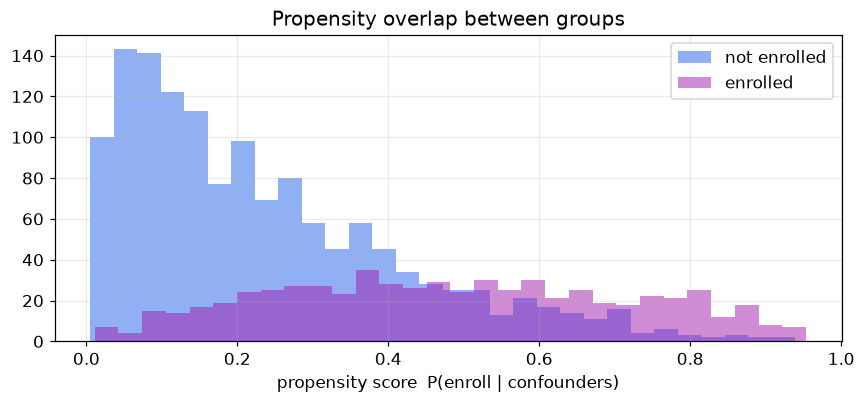

IPW estimate of the effect = $100.9   (regression $117, true $120)
  weighted prior_spend   : enrolled   186.0  vs  control   201.8
  weighted tenure_months : enrolled    31.0  vs  control    31.2


In [5]:
X = df[["prior_spend", "tenure_months"]].values
ps = LogisticRegression(max_iter=1000).fit(X, df.enrolled).predict_proba(X)[:, 1]
df["pscore"] = ps
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(df.loc[df.enrolled==0, "pscore"], bins=30, alpha=0.5, color=BL, label="not enrolled")
ax.hist(df.loc[df.enrolled==1, "pscore"], bins=30, alpha=0.5, color=FU, label="enrolled")
ax.set_xlabel("propensity score  P(enroll | confounders)"); ax.set_title("Propensity overlap between groups"); ax.legend()
plt.tight_layout(); plt.show()

w = np.where(df.enrolled==1, 1/ps, 1/(1-ps))          # inverse-probability weights
ipw = (np.sum(w*df.enrolled*df.spend)/np.sum(w*df.enrolled)
       - np.sum(w*(1-df.enrolled)*df.spend)/np.sum(w*(1-df.enrolled)))
print(f"IPW estimate of the effect = ${ipw:.1f}   (regression ${adj:.0f}, true ${TRUE})")
# balance check: weighted confounder means should move closer together
for col in ["prior_spend", "tenure_months"]:
    t = np.average(df.loc[df.enrolled==1, col], weights=w[df.enrolled==1])
    ctl = np.average(df.loc[df.enrolled==0, col], weights=w[df.enrolled==0])
    print(f"  weighted {col:14s}: enrolled {t:7.1f}  vs  control {ctl:7.1f}")

## DEMO 4 &middot; Four numbers, one picture
The naive estimate stands alone and wrong; every method that blocks the backdoor lands near the true 120 dollars. The gap between the red bar and the rest IS the confounding bias.

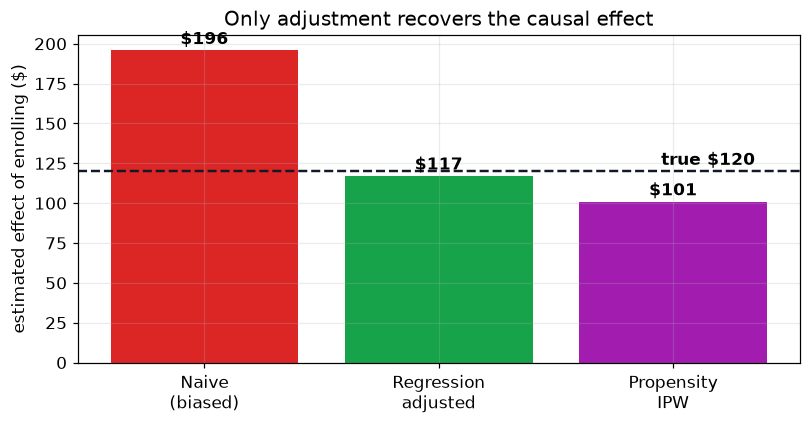

In [6]:
vals = {"Naive\n(biased)": naive, "Regression\nadjusted": adj, "Propensity\nIPW": ipw}
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(list(vals), list(vals.values()), color=[RD, GR, FU])
ax.axhline(TRUE, color="#111827", ls="--", lw=1.6); ax.text(2.35, TRUE+4, f"true ${TRUE}", ha="right", fontweight="bold")
for b, v in zip(bars, vals.values()): ax.text(b.get_x()+b.get_width()/2, v+4, f"${v:.0f}", ha="center", fontweight="bold")
ax.set_ylabel("estimated effect of enrolling ($)"); ax.set_title("Only adjustment recovers the causal effect")
plt.tight_layout(); plt.show()

### Wrap-up
The naive **+196 dollars** was not noisy, it was systematically wrong, because enrollees were bigger spenders before the program. Blocking the backdoor (regression **+117 dollars**, IPW **+101 dollars**) recovered the true **+120 dollars**. Same discipline every time: draw the confounders, adjust for them, and state the no-unmeasured-confounders assumption you are leaning on. Next in Part XXIV: **Survival Analysis**.